In [108]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from noise import pnoise2
print("ready!")

ready!


In [109]:
# A tiny world, so we can actually see what's happening
width = 120
height = 90
np.random.seed(98)

# Fill it with random 0s and 1s
# 0 = ocean, 1 = land
world = (np.random.random((height, width)) < 0.45).astype(int)

print(world)

[[0 0 1 ... 1 1 0]
 [1 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 1 1 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [1 1 0 ... 0 1 1]]


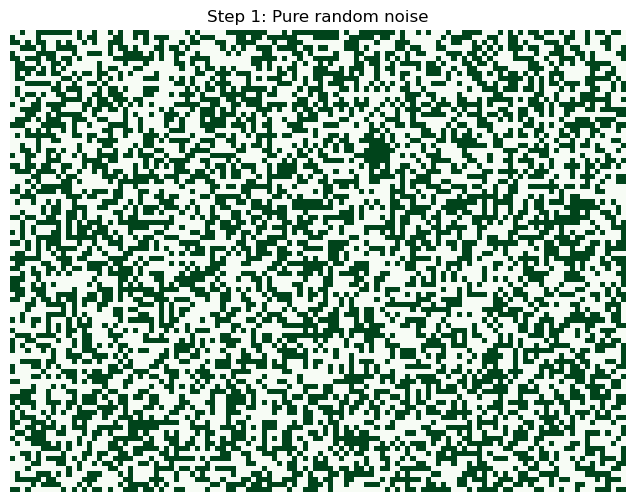

In [110]:
plt.figure(figsize=(8, 6))
plt.imshow(world, cmap='Greens', interpolation='nearest')
plt.axis('off')
plt.title("Step 1: Pure random noise")
plt.show()

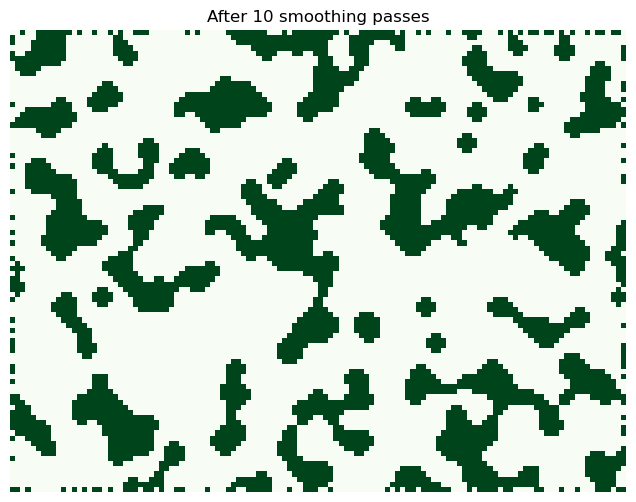

In [111]:
for step in range(10):
    new_world = world.copy()
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            neighbours = world[y-1:y+2, x-1:x+2].sum()
            if neighbours >= 5:
                new_world[y, x] = 1
            else:
                new_world[y, x] = 0
    world = new_world

plt.figure(figsize=(8, 6))
plt.imshow(world, cmap='Greens', interpolation='nearest')
plt.axis('off')
plt.title("After 10 smoothing passes")
plt.show()

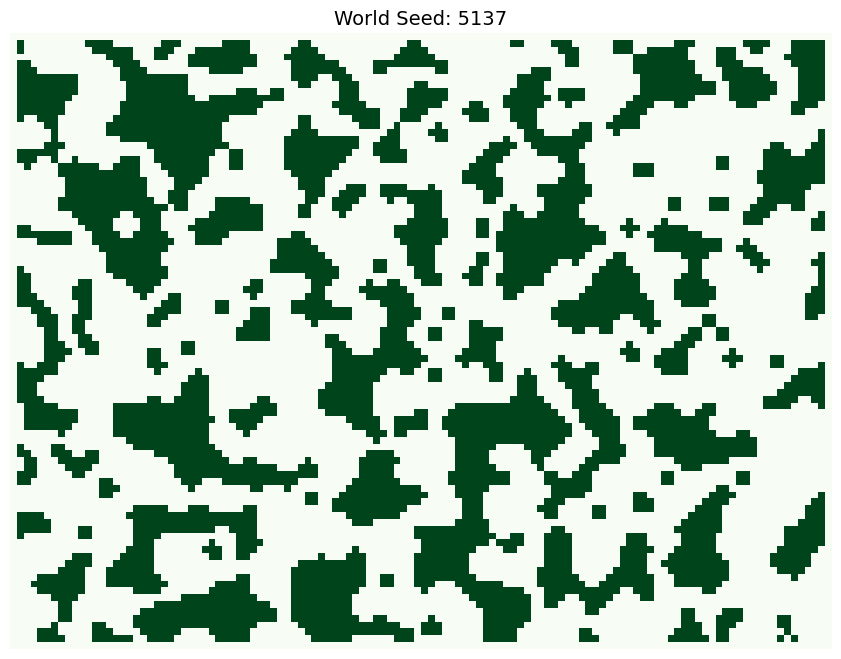

In [112]:
import numpy as np
import matplotlib.pyplot as plt

# === SETTINGS — tweak these ===
SEED = 5137          # your world's identity — change for a new world
WIDTH = 120
HEIGHT = 90
LAND_PROBABILITY = 0.39 # 0.35 = more ocean, 0.55 = more land
SMOOTHING_STEPS = 20

# === GENERATE ===
np.random.seed(SEED)
world = (np.random.random((HEIGHT, WIDTH)) < LAND_PROBABILITY).astype(int)

for _ in range(SMOOTHING_STEPS):
    new_world = world.copy()
    for y in range(1, HEIGHT - 1):
        for x in range(1, WIDTH - 1):
            neighbours = world[y-1:y+2, x-1:x+2].sum()
            if neighbours >= 5:
                new_world[y, x] = 1
            elif neighbours <= 3:    # only kill land if it's VERY isolated
                new_world[y, x] = 0
# otherwise — leave it as it was
    world = new_world

# Edges always ocean — cleaner coastlines
world[0, :] = world[-1, :] = world[:, 0] = world[:, -1] = 0

# === DRAW ===
plt.figure(figsize=(12, 8))
plt.imshow(world, cmap='Greens', interpolation='nearest')
plt.axis('off')
plt.title(f"World Seed: {SEED}", fontsize=14)
plt.show()

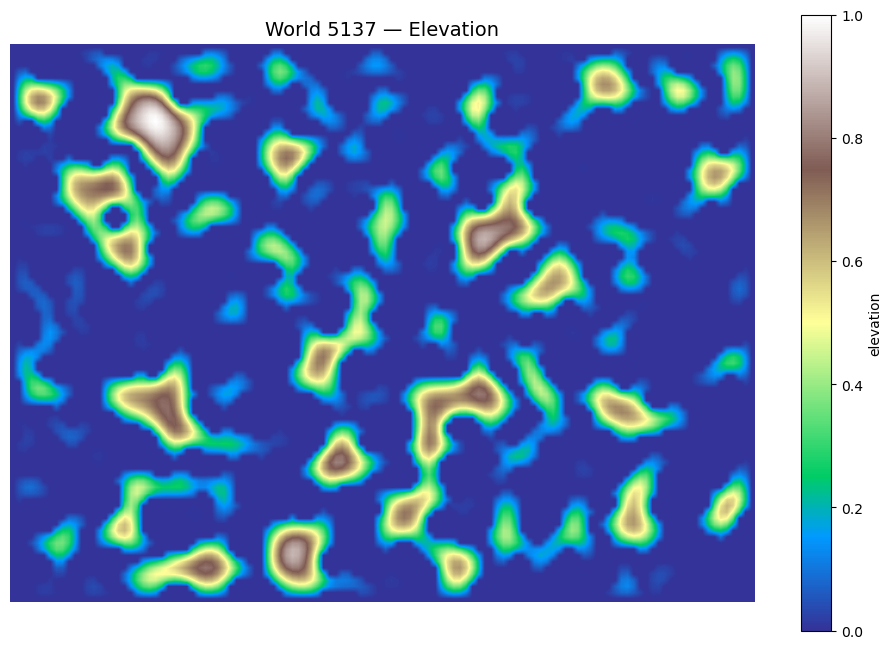

In [113]:
# === ELEVATION ===
# Start with random elevation on land cells only
elevation = np.random.random((HEIGHT, WIDTH))
elevation[world == 0] = 0  # ocean has no elevation

# Smooth the elevation several times so mountains cluster naturally
for _ in range(8):
    new_elevation = elevation.copy()
    for y in range(1, HEIGHT - 1):
        for x in range(1, WIDTH - 1):
            if world[y, x] == 1:  # only smooth land cells
                neighbourhood = elevation[y-1:y+2, x-1:x+2]
                new_elevation[y, x] = neighbourhood.mean()
    elevation = new_elevation

# Stretch elevation to use full range
land_mask = world == 1
e_min = elevation[land_mask].min()
e_max = elevation[land_mask].max()
elevation[land_mask] = (elevation[land_mask] - e_min) / (e_max - e_min)

# === DRAW ===
plt.figure(figsize=(12, 8))
plt.imshow(elevation, cmap='terrain', interpolation='bilinear')
plt.axis('off')
plt.title(f"World {SEED} — Elevation", fontsize=14)
plt.colorbar(label='elevation')
plt.show()

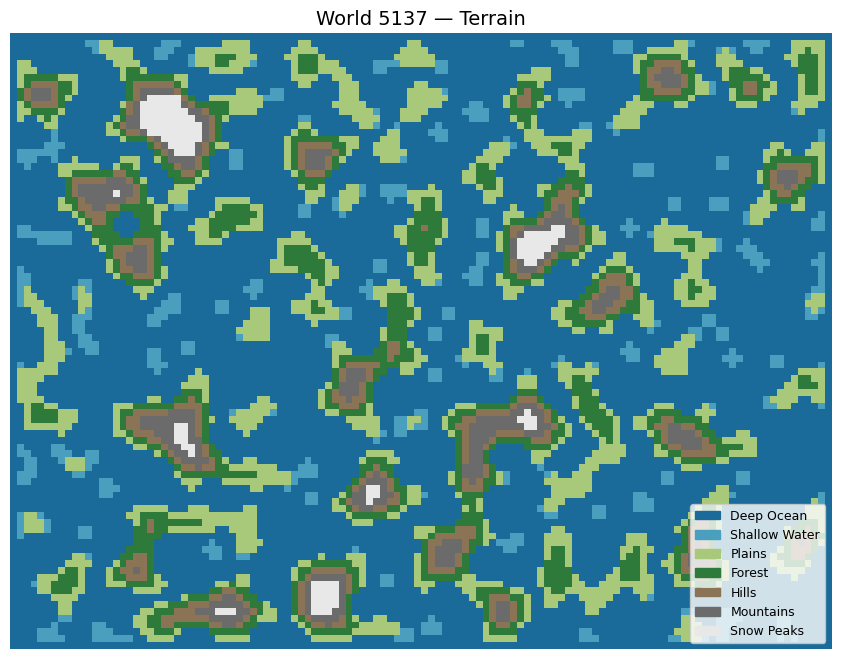

In [114]:
terrain = np.zeros((HEIGHT, WIDTH), dtype=int)

# Threshold table: (max_elevation, terrain_type)
thresholds = [
    (0.00, 0),  # deep ocean
    (0.05, 1),  # shallow water
    (0.25, 2),  # plains
    (0.45, 3),  # forest
    (0.60, 4),  # hills
    (0.75, 5),  # mountains
    (1.00, 6),  # snow peaks
]

for y in range(HEIGHT):
    for x in range(WIDTH):
        e = elevation[y, x]
        for threshold, zone in thresholds:
            if e <= threshold:
                terrain[y, x] = zone
                break

# === DRAW ===
colors = [
    '#1a6b9a',   # 0 deep ocean
    '#4a9ebe',   # 1 shallow water
    '#a8c87a',   # 2 lowland plains
    '#2d7a3a',   # 3 forest
    '#8b7355',   # 4 hills
    '#6b6b6b',   # 5 mountains
    '#e8e8e8',   # 6 snow peaks
]

cmap = mcolors.ListedColormap(colors)

plt.figure(figsize=(12, 8))
plt.imshow(terrain, cmap=cmap, vmin=0, vmax=6, interpolation='nearest')
plt.axis('off')
plt.title(f"World {SEED} — Terrain", fontsize=14)

# Legend
import matplotlib.patches as mpatches
labels = ['Deep Ocean', 'Shallow Water', 'Plains', 'Forest', 'Hills', 'Mountains', 'Snow Peaks']
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(7)]
plt.legend(handles=patches, loc='lower right', fontsize=9)

plt.show()

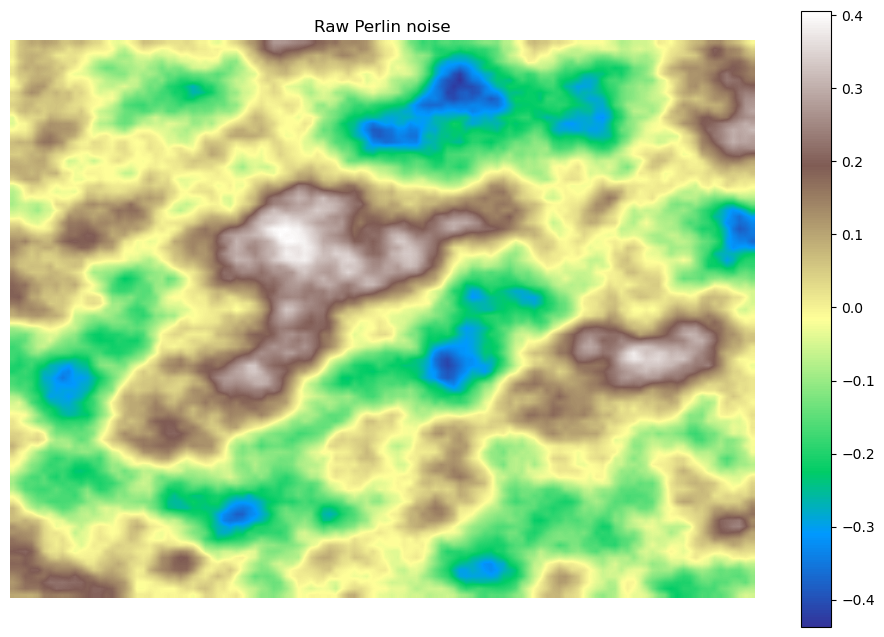

In [115]:
SCALE = 4.0   # try 2.0, 4.0, 8.0 and see what changes

perlin = np.zeros((HEIGHT, WIDTH))
for y in range(HEIGHT):
    for x in range(WIDTH):
        perlin[y, x] = pnoise2(x / WIDTH * SCALE, 
                                y / HEIGHT * SCALE, 
                                octaves=6,
                                persistence=0.5,
                                lacunarity=2.0,
                                repeatx=1024,
                                repeaty=1024)

plt.figure(figsize=(12, 8))
plt.imshow(perlin, cmap='terrain', interpolation='bilinear')
plt.colorbar()
plt.axis('off')
plt.title("Raw Perlin noise")
plt.show()

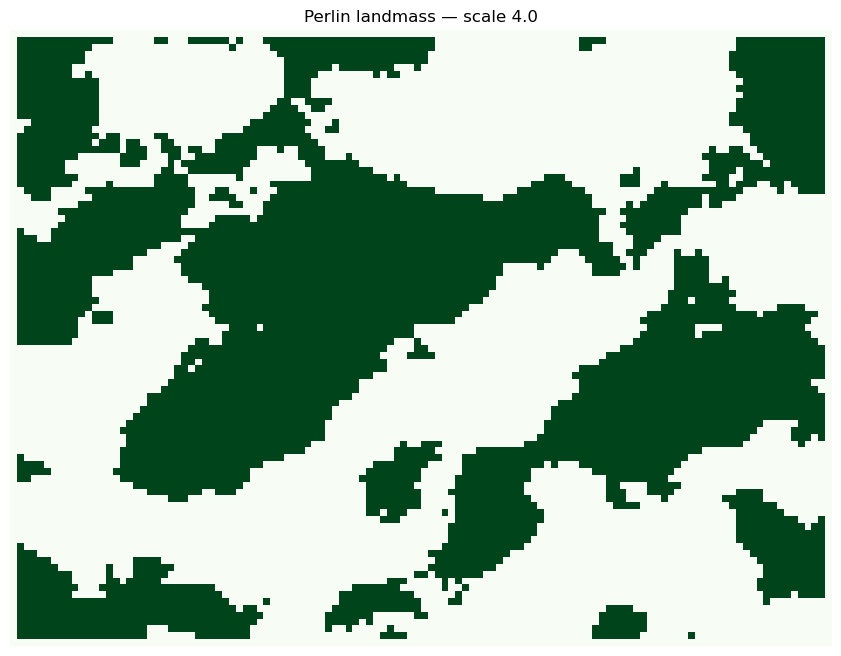

In [116]:
LAND_THRESHOLD = 0.0  # values above this = land, below = ocean

world_perlin = (perlin > LAND_THRESHOLD).astype(int)
world_perlin[0, :] = world_perlin[-1, :] = world_perlin[:, 0] = world_perlin[:, -1] = 0

plt.figure(figsize=(12, 8))
plt.imshow(world_perlin, cmap='Greens', interpolation='nearest')
plt.axis('off')
plt.title(f"Perlin landmass — scale {SCALE}")
plt.show()

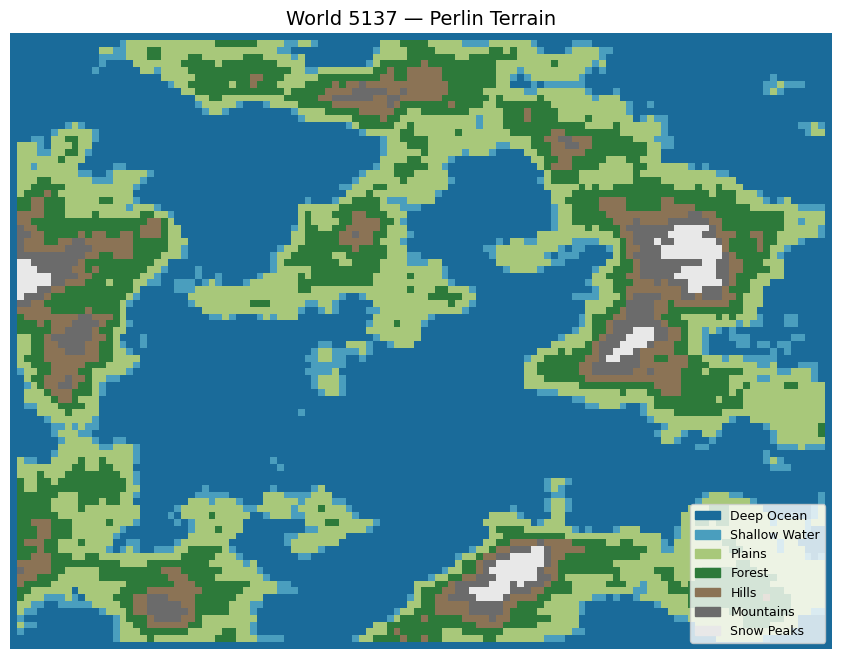

In [117]:
from noise import pnoise2

# === SETTINGS ===
SEED = 5137
WIDTH = 120
HEIGHT = 90
SCALE = 4.0
SEA_LEVEL = 0.0  # adjust to get more/less land

# === GENERATE ELEVATION VIA PERLIN ===
np.random.seed(SEED)
# Random offset so different seeds give different worlds
offset_x = np.random.randint(0, 10000)
offset_y = np.random.randint(0, 10000)

elevation = np.zeros((HEIGHT, WIDTH))
for y in range(HEIGHT):
    for x in range(WIDTH):
        elevation[y, x] = pnoise2(
            (x + offset_x) / WIDTH * SCALE,
            (y + offset_y) / HEIGHT * SCALE,
            octaves=6,
            persistence=0.5,
            lacunarity=2.0
        )

# === LAND/OCEAN MASK ===
world = (elevation > SEA_LEVEL).astype(int)
world[0, :] = world[-1, :] = world[:, 0] = world[:, -1] = 0
elevation[world == 0] = 0

# === NORMALISE LAND ELEVATION ===
land_mask = world == 1
e_min = elevation[land_mask].min()
e_max = elevation[land_mask].max()
elevation[land_mask] = (elevation[land_mask] - e_min) / (e_max - e_min)

# === TERRAIN CLASSIFICATION ===
thresholds = [
    (0.00, 0),  # deep ocean
    (0.05, 1),  # shallow water
    (0.25, 2),  # plains
    (0.45, 3),  # forest
    (0.60, 4),  # hills
    (0.75, 5),  # mountains
    (1.00, 6),  # snow peaks
]

terrain = np.zeros((HEIGHT, WIDTH), dtype=int)
for y in range(HEIGHT):
    for x in range(WIDTH):
        e = elevation[y, x]
        for threshold, zone in thresholds:
            if e <= threshold:
                terrain[y, x] = zone
                break

# === DRAW ===
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

colors = [
    '#1a6b9a',   # deep ocean
    '#4a9ebe',   # shallow water
    '#a8c87a',   # plains
    '#2d7a3a',   # forest
    '#8b7355',   # hills
    '#6b6b6b',   # mountains
    '#e8e8e8',   # snow peaks
]

cmap = mcolors.ListedColormap(colors)
plt.figure(figsize=(12, 8))
plt.imshow(terrain, cmap=cmap, vmin=0, vmax=6, interpolation='nearest')
plt.axis('off')
plt.title(f"World {SEED} — Perlin Terrain", fontsize=14)

labels = ['Deep Ocean', 'Shallow Water', 'Plains', 'Forest', 'Hills', 'Mountains', 'Snow Peaks']
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(7)]
plt.legend(handles=patches, loc='lower right', fontsize=9)
plt.show()

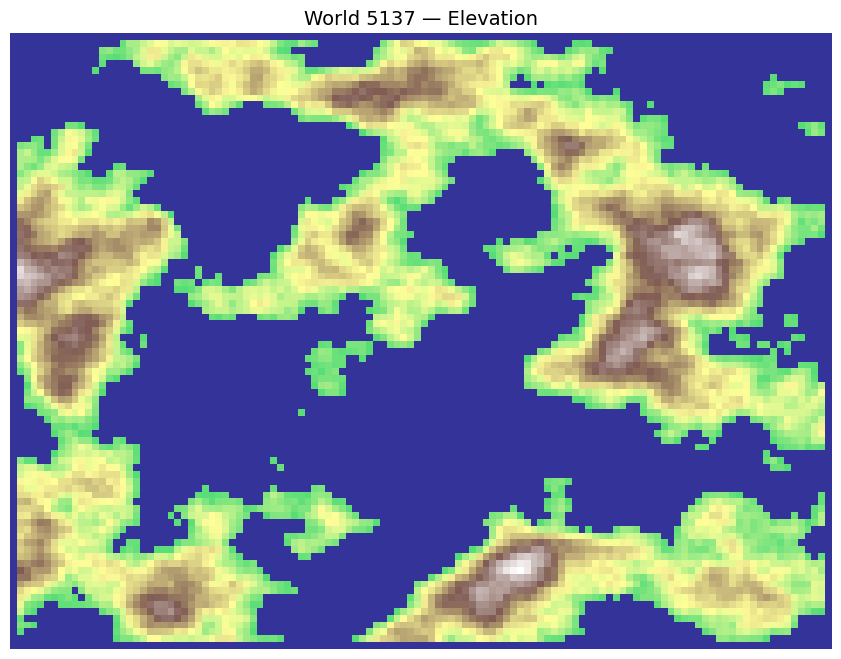

In [118]:
# Create a display version — ocean cells get a negative value
elevation_display = elevation.copy()
elevation_display[world == 0] = -0.5  # force ocean into blue zone

plt.figure(figsize=(12, 8))
plt.imshow(elevation_display, cmap='terrain', interpolation='nearest', vmin=-0.5, vmax=1.0)
plt.axis('off')
plt.title(f"World {SEED} — Elevation", fontsize=14)
plt.show()

In [119]:
def find_starting_location(terrain, existing_starts=[], min_distance=20):
    """Find a suitable starting cell for a new civilisation"""
    # Get all plains and forest cells
    suitable = []
    for y in range(HEIGHT):
        for x in range(WIDTH):
            if terrain[y, x] in [2, 3]:  # plains or forest
                # Check distance from existing starts
                too_close = False
                for (sy, sx) in existing_starts:
                    dist = np.sqrt((y - sy)**2 + (x - sx)**2)
                    if dist < min_distance:
                        too_close = True
                        break
                if not too_close:
                    suitable.append((y, x))
    
    if suitable:
        return suitable[np.random.randint(len(suitable))]
    return None

# Test it
start = find_starting_location(terrain)
print(f"Starting location: {start}")
print(f"Terrain there: {terrain[start[0], start[1]]}")

Starting location: (37, 50)
Terrain there: 2


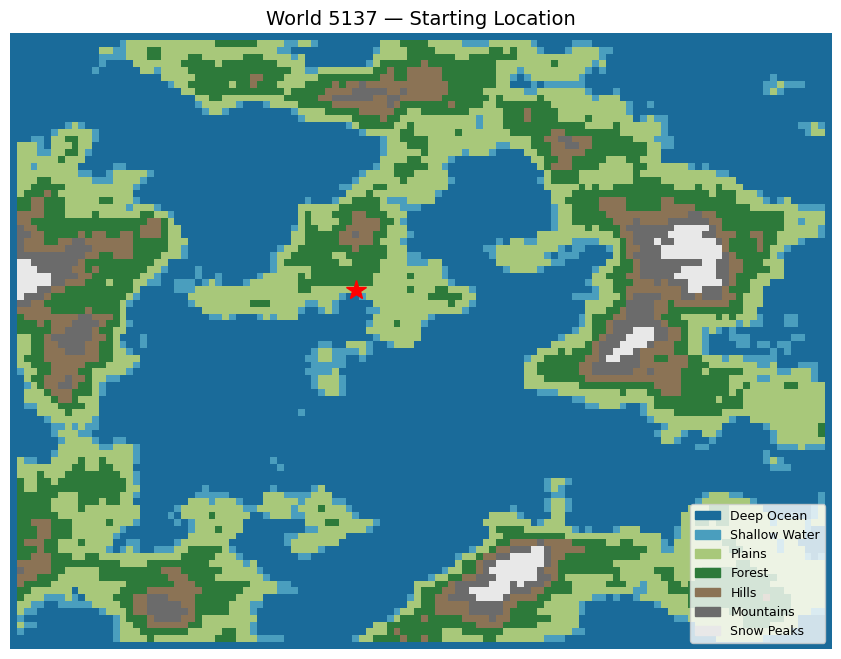

In [120]:
plt.figure(figsize=(12, 8))
plt.imshow(terrain, cmap=cmap, vmin=0, vmax=6, interpolation='nearest')

# Mark the starting location with a dot
plt.plot(start[1], start[0], 'r*', markersize=15)

plt.axis('off')
plt.title(f"World {SEED} — Starting Location", fontsize=14)
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(7)]
plt.legend(handles=patches, loc='lower right', fontsize=9)
plt.show()

In [121]:
def create_civilisation(name, color, start):
    return {
        'name': name,
        'color': color,
        'start': start,
        'spread_chance': 0.3,        # 30% chance to spread each step
        'preferred_terrain': [2, 3], # plains and forest
        'passable_terrain': [2, 3, 4], # can also move through hills, slowly
        'cells': {start},            # set of cells this civ occupies
    }

# Create our first civilisation
civ1 = create_civilisation('Aldoria', '#e63946', start)

print(f"{civ1['name']} founded at {civ1['start']}")
print(f"Currently occupies {len(civ1['cells'])} cell(s)")

Aldoria founded at (37, 50)
Currently occupies 1 cell(s)


In [122]:
def spread_civilisation(civ, terrain, all_civs):
    # Collect all cells occupied by ANY civilisation
    occupied = set()
    for c in all_civs:
        occupied.update(c['cells'])
    
    new_cells = set()
    
    for (y, x) in civ['cells']:
        # Check all 4 neighbours (not diagonal for now)
        for (ny, nx) in [(y-1,x), (y+1,x), (y,x-1), (y,x+1)]:
            # Stay within bounds
            if 0 <= ny < HEIGHT and 0 <= nx < WIDTH:
                # Not already occupied
                if (ny, nx) not in occupied:
                    # Terrain must be passable
                    if terrain[ny, nx] in civ['passable_terrain']:
                        # Roll the dice
                        if np.random.random() < civ['spread_chance']:
                            new_cells.add((ny, nx))
    
    civ['cells'].update(new_cells)
    return len(new_cells)

# Test one step
grew = spread_civilisation(civ1, terrain, [civ1])
print(f"Aldoria grew by {grew} cells, now occupies {len(civ1['cells'])} cells")

Aldoria grew by 0 cells, now occupies 1 cells


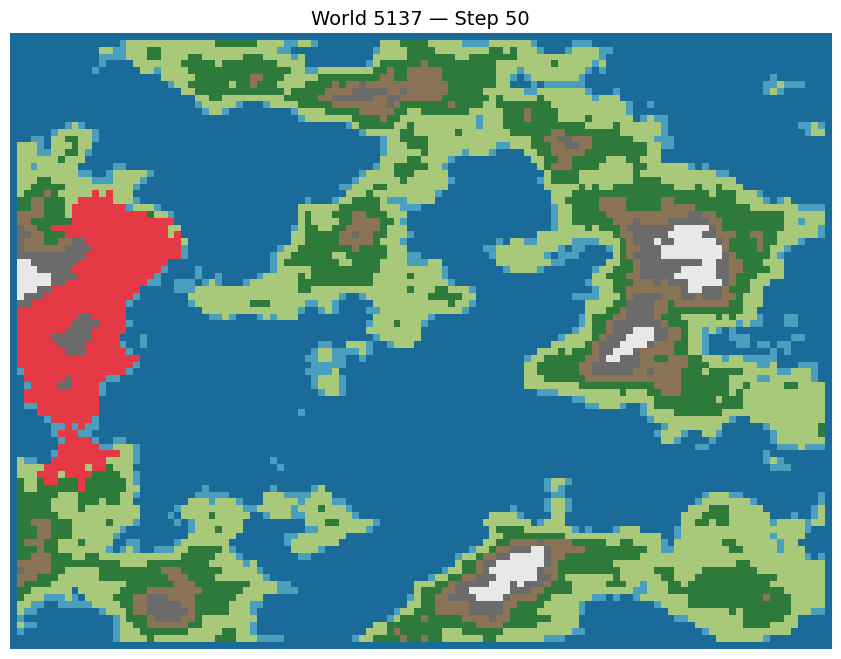

Aldoria occupies 457 cells after 50 steps


In [123]:
def draw_civilisations(terrain, civs, step=0):
    # Start with terrain as base
    display = np.zeros((HEIGHT, WIDTH, 3))
    
    # Convert terrain to RGB using our colors
    for y in range(HEIGHT):
        for x in range(WIDTH):
            hex_color = colors[terrain[y, x]]
            r, g, b = mcolors.hex2color(hex_color)
            display[y, x] = [r, g, b]
    
    # Paint civilisation cells on top
    for civ in civs:
        r, g, b = mcolors.hex2color(civ['color'])
        for (y, x) in civ['cells']:
            display[y, x] = [r, g, b]
    
    plt.figure(figsize=(12, 8))
    plt.imshow(display, interpolation='nearest')
    plt.axis('off')
    plt.title(f"World {SEED} — Step {step}", fontsize=14)
    plt.show()

# Reset and run fresh
start = find_starting_location(terrain)
civ1 = create_civilisation('Aldoria', '#e63946', start)

# Run 50 steps
for step in range(50):
    spread_civilisation(civ1, terrain, [civ1])

draw_civilisations(terrain, [civ1], step=50)
print(f"Aldoria occupies {len(civ1['cells'])} cells after 50 steps")

Aldoria founded at (66, 9), terrain: 3
Sylvara founded at (31, 20), terrain: 3
Dornheim founded at (14, 93), terrain: 2
Vaelthar founded at (37, 53), terrain: 2


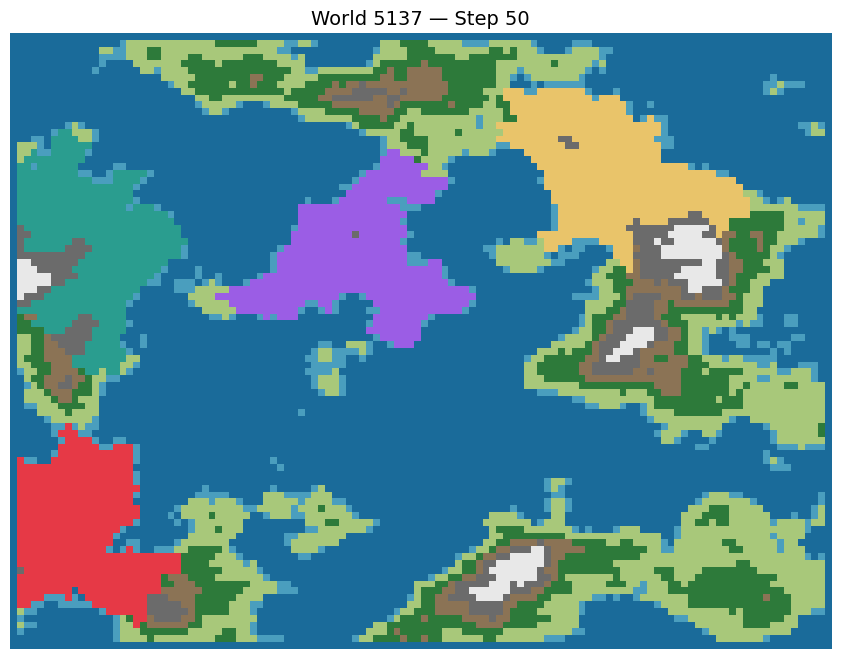

Aldoria: 420 cells
Sylvara: 447 cells
Dornheim: 485 cells
Vaelthar: 458 cells


In [124]:
# Reset everything and create multiple civilisations
civ_definitions = [
    ('Aldoria',  '#e63946'),  # red
    ('Sylvara',  '#2a9d8f'),  # teal
    ('Dornheim', '#e9c46a'),  # yellow
    ('Vaelthar', '#9b5de5'),  # purple
]

civs = []
starts = []

for name, color in civ_definitions:
    start = find_starting_location(terrain, existing_starts=starts, min_distance=20)
    if start is not None:
        starts.append(start)
        civs.append(create_civilisation(name, color, start))
        print(f"{name} founded at {start}, terrain: {terrain[start[0], start[1]]}")
    else:
        print(f"Could not place {name} — no suitable location found!")

# Run 50 steps
for step in range(50):
    for civ in civs:
        spread_civilisation(civ, terrain, civs)

draw_civilisations(terrain, civs, step=50)

for civ in civs:
    print(f"{civ['name']}: {len(civ['cells'])} cells")